In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [91]:
from sklearn.datasets import fetch_california_housing

In [92]:
data = fetch_california_housing()

In [93]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [94]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [95]:
data.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [96]:
data.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [97]:
df = pd.DataFrame(data.data, columns = data.feature_names)

In [98]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [99]:
df['price'] = data.target

In [100]:
#multicollinearity>> when one feature is explained by all other features(more than 2)
#when two feature>> correlation
#when more than two feature>> multicollinearity>> clustermap, VIF

In [101]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


<Axes: >

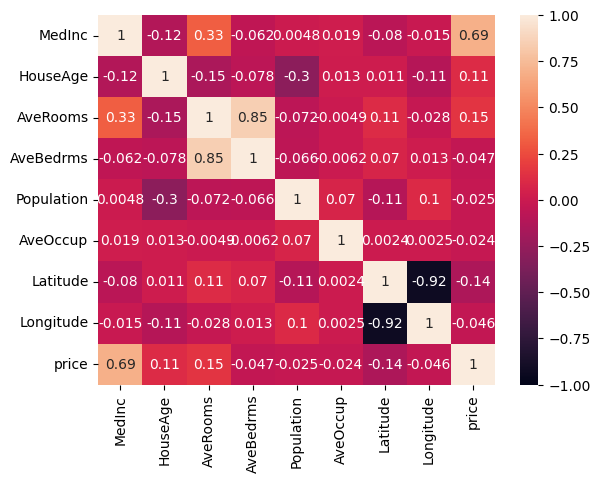

In [102]:
sns.heatmap(df.corr(), annot=True, vmin= -1, vmax= 1)

<Figure size 500x500 with 0 Axes>

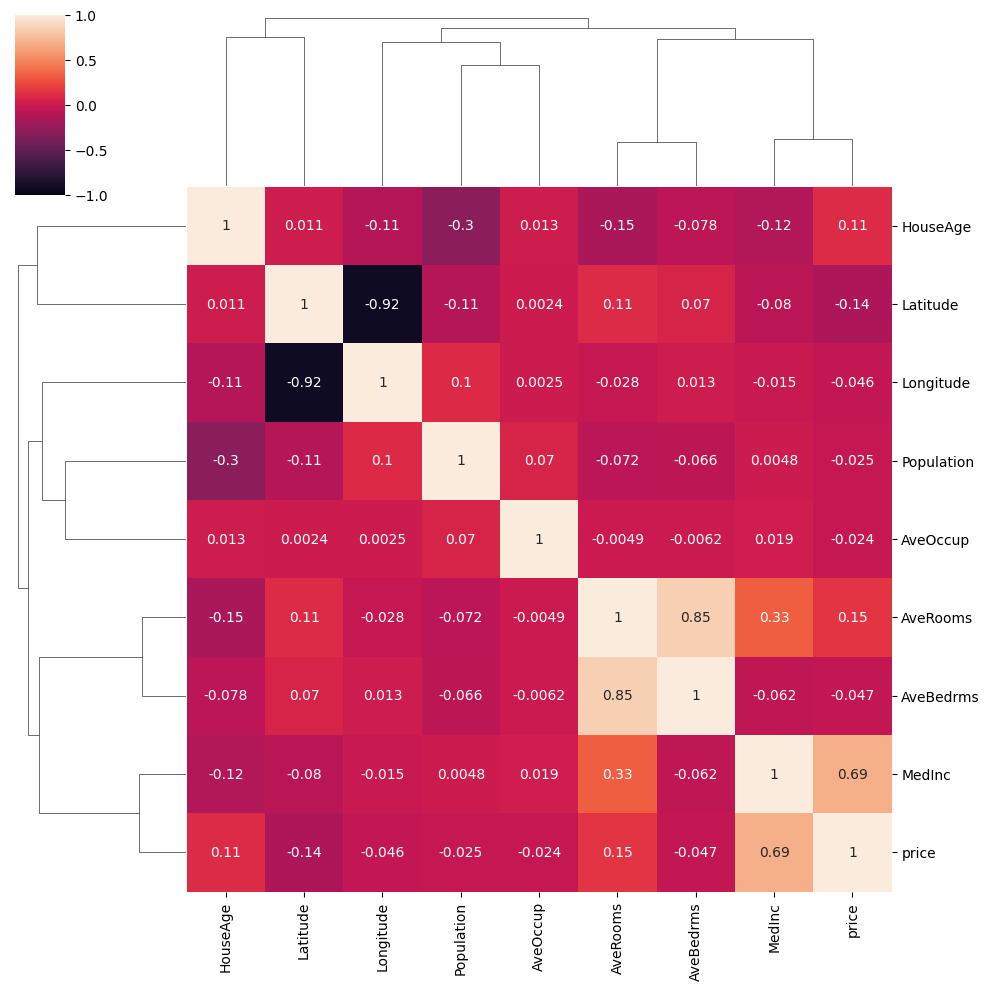

In [103]:
#clustermap table shows group cluster relationship

plt.figure(figsize=(5, 5))
sns.clustermap(df.corr(), vmin = -1, vmax = 1, annot = True)
plt.show()

In [104]:
#problem with the above plot interpretation>> you understand among features together 
#but don't understand how much>> lack of quatitative measure, so we study vif

In [105]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\sagar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [106]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [107]:
vif = pd.DataFrame()
vif["Feature"] = df.columns


In [108]:
vif['VIF'] =[ variance_inflation_factor(df.values, i) for i in range(len(df.columns))]


In [109]:
vif

,Feature,VIF
0,MedInc,19.624998
1,HouseAge,7.592663
2,AveRooms,47.956351
3,AveBedrms,45.358192
4,Population,2.936078
5,AveOccup,1.099530
6,Latitude,568.497332
7,Longitude,640.064211
8,price,9.285659


In [110]:
#if VIF is > 10, drop the feature one by one>> here highest is longitude

In [111]:
df1 = df.copy()
df1

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [112]:
df1.drop("Longitude", axis=1, inplace =True)

In [113]:
df1

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,3.422
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,0.847


In [114]:
vif = pd.DataFrame()
vif["Feature"] = df1.columns
vif['VIF'] =[ variance_inflation_factor(df1.values, i) for i in range(len(df1.columns))]

In [115]:
vif

,Feature,VIF
0,MedInc,18.639889
1,HouseAge,7.346583
2,AveRooms,44.714760
3,AveBedrms,42.072000
4,Population,2.796280
5,AveOccup,1.099394
6,Latitude,22.873934
7,price,9.193500


In [116]:
df1.drop('AveRooms', axis = 1, inplace=True)
df1


,MedInc,HouseAge,AveBedrms,Population,AveOccup,Latitude,price
0,8.3252,41.0,1.023810,322.0,2.555556,37.88,4.526
1,8.3014,21.0,0.971880,2401.0,2.109842,37.86,3.585
2,7.2574,52.0,1.073446,496.0,2.802260,37.85,3.521
3,5.6431,52.0,1.073059,558.0,2.547945,37.85,3.413
4,3.8462,52.0,1.081081,565.0,2.181467,37.85,3.422
...,...,...,...,...,...,...,...
20635,1.5603,25.0,1.133333,845.0,2.560606,39.48,0.781
20636,2.5568,18.0,1.315789,356.0,3.122807,39.49,0.771
20637,1.7000,17.0,1.120092,1007.0,2.325635,39.43,0.923
20638,1.8672,18.0,1.171920,741.0,2.123209,39.43,0.847


In [117]:
vif = pd.DataFrame()
vif["Feature"] = df1.columns
vif['VIF'] =[ variance_inflation_factor(df1.values, i) for i in range(len(df1.columns))]
vif

,Feature,VIF
0,MedInc,10.584081
1,HouseAge,7.260588
2,AveBedrms,6.440667
3,Population,2.762794
4,AveOccup,1.098719
5,Latitude,22.094483
6,price,8.674858


In [118]:
df1.drop('Latitude', axis=1, inplace=True)
df1

,MedInc,HouseAge,AveBedrms,Population,AveOccup,price
0,8.3252,41.0,1.023810,322.0,2.555556,4.526
1,8.3014,21.0,0.971880,2401.0,2.109842,3.585
2,7.2574,52.0,1.073446,496.0,2.802260,3.521
3,5.6431,52.0,1.073059,558.0,2.547945,3.413
4,3.8462,52.0,1.081081,565.0,2.181467,3.422
...,...,...,...,...,...,...
20635,1.5603,25.0,1.133333,845.0,2.560606,0.781
20636,2.5568,18.0,1.315789,356.0,3.122807,0.771
20637,1.7000,17.0,1.120092,1007.0,2.325635,0.923
20638,1.8672,18.0,1.171920,741.0,2.123209,0.847


In [119]:
vif = pd.DataFrame()
vif["Feature"] = df1.columns
vif['VIF'] =[ variance_inflation_factor(df1.values, i) for i in range(len(df1.columns))]
vif

,Feature,VIF
0,MedInc,8.855104
1,HouseAge,4.156145
2,AveBedrms,4.264253
3,Population,2.223926
4,AveOccup,1.098671
5,price,8.607339


In [120]:
#Now all are < 10. Now we can build the model

In [121]:
x = df1.iloc[:, :-1] #independent variable
y = df1.iloc[:, -1] #target variable

In [122]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: price, Length: 20640, dtype: float64

In [123]:
from sklearn.model_selection import train_test_split

In [124]:
x_train,  x_test, y_train, y_test = train_test_split(x,y,test_size=0.30, random_state=1)

In [125]:
#scaling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [126]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [127]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [128]:
from sklearn.linear_model import LinearRegression

In [129]:
model = LinearRegression()

In [130]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [131]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [132]:
model.coef_

array([ 0.8295202 ,  0.23888438,  0.02058888,  0.03902186, -0.05185743])

In [133]:
model.intercept_

np.float64(2.0765314825581394)

In [134]:
y_pred = model.predict(x_test)
y_pred

array([1.99486815, 1.39443153, 2.46691805, ..., 1.83891855, 1.28083607,
       1.20666527], shape=(6192,))

In [135]:
#performance matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [136]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))
print(r2_score(y_test,y_pred))

0.6046846522578226
0.6544937093127864
0.8090078549141451
0.5021661718778507


In [137]:
score = r2_score(y_test,y_pred)

In [138]:
#adjusted rSquare
print(1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1))

0.5017637843672444


In [139]:
#here the no if features were low, thats why it is possible to dropeed and check the feature one by one 
# but what if the no of features are 1000 in number  

In [140]:
#Recursive Feature Elimination

x = df.iloc[:, :-1]
y = df.iloc[:,-1]

In [141]:
from sklearn.feature_selection import RFE

In [142]:
rfe = RFE(LinearRegression(), n_features_to_select=5)
rfe

,estimator,LinearRegression()
,n_features_to_select,5
,step,1
,verbose,0
,importance_getter,'auto'
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [143]:
rfe.fit(x,y)

,estimator,LinearRegression()
,n_features_to_select,5
,step,1
,verbose,0
,importance_getter,'auto'
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [144]:
rfe.support_

array([ True, False,  True,  True, False, False,  True,  True])

In [145]:
x.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [146]:
rfe.ranking_

array([1, 2, 1, 1, 4, 3, 1, 1])

In [147]:
rfe.predict(x)

array([3.98910415, 4.03191679, 3.44103761, ..., 0.22630645, 0.36574672,
       0.57907858], shape=(20640,))